In [94]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from GB84 import variables, rho_m, v,cloud_heights, h_out, phi, f, non_dim_numbers
from kalman_filter_2 import kalman_filter as kf
from scipy import signal
from scipy.stats import pearsonr

In [95]:
slice_str = "2024-07-01 00:00:00, 2024-07-31 23:59:00"
slice_tuple = tuple(slice_str.split(", "))

### Testing the model

In [96]:
measurements = xr.open_mfdataset(r'C:\Users\chari\Home\TU Delft\TU-Delft\thesis\rainmodel_conc\cesar_surface_meteo_lc1_t10_v1.0_202407.nc')

In [97]:
measurements

<xarray.Dataset> Size: 411kB
Dimensions:          (time: 4464, day_in_time_interval: 31, nv: 2)
Coordinates:
  * time             (time) datetime64[ns] 36kB 2024-07-01 ... 2024-07-31T23:...
Dimensions without coordinates: day_in_time_interval, nv
Data variables: (12/22)
    iso_dataset      |S1 1B ...
    product          |S1 1B ...
    station_details  |S1 1B ...
    date             (time) int32 18kB dask.array<chunksize=(4464,), meta=np.ndarray>
    valid_dates      (day_in_time_interval) int8 31B dask.array<chunksize=(31,), meta=np.ndarray>
    time_bnds        (time, nv) datetime64[ns] 71kB dask.array<chunksize=(4464, 2), meta=np.ndarray>
    ...               ...
    F010             (time) float32 18kB dask.array<chunksize=(4464,), meta=np.ndarray>
    IF010            (time) float32 18kB dask.array<chunksize=(4464,), meta=np.ndarray>
    D010             (time) float32 18kB dask.array<chunksize=(4464,), meta=np.ndarray>
    ID010            (time) float32 18kB dask.array<chunksize=(4464,), meta=np.ndarray>
    TD002            (time) float32 18kB dask.array<chunksize=(4464,), meta=np.ndarray>
    RH002            (time) float32 18kB dask.array<chunksize=(4464,), meta=np.ndarray>
Attributes:
    institution:              Royal Netherlands Meteorological Institute (KNMI)
    comment:                  none
    Conventions:              CF-1.4
    location:                 CESAR observatory, the Netherlands
    file_creation_date_time:  20240826 10:49:12 (UTC)
    references:               cesar_surface_meteo_lc1_t10_v1.0.pdf @ http://w...
    history:                  Continuous observations are performed, gap fill...

#### Radiometer LWC 

In [98]:
cabaw = xr.open_mfdataset(r'C:\Users\chari\Home\TU Delft\TU-Delft\thesis\rainmodel_conc\data\Cabaw_radiometer\*.nc')
reference_date = np.datetime64("2024-07-01")

# Convert minutes into datetime
#datetime_values = reference_date + measurements.time.astype("timedelta64[m]")
#measurements['time'] = datetime_values

july = cabaw.sel(time=slice('2024-07-01', '2024-08-01'))

In [99]:
july

<xarray.Dataset> Size: 57MB
Dimensions:       (time: 1794345)
Coordinates:
  * time          (time) datetime64[ns] 14MB 2024-07-01 ... 2024-08-01T23:59:59
Data variables:
    iwv           (time) float32 7MB dask.array<chunksize=(75427,), meta=np.ndarray>
    lwp           (time) float32 7MB dask.array<chunksize=(75427,), meta=np.ndarray>
    zenith_angle  (time) float32 7MB dask.array<chunksize=(75427,), meta=np.ndarray>
    latitude      (time) float32 7MB 51.97 51.97 51.97 ... 51.97 51.97 51.97
    longitude     (time) float32 7MB 4.927 4.927 4.927 ... 4.927 4.927 4.927
    altitude      (time) float32 7MB -1.0 -1.0 -1.0 -1.0 ... -1.0 -1.0 -1.0 -1.0
Attributes: (12/15)
    Conventions:                  CF-1.8
    cloudnetpy_version:           1.61.12
    file_uuid:                    1737a835-5c0c-467b-a2e0-01574fd7961d
    cloudnet_file_type:           mwr
    title:                        HATPRO microwave radiometer from Cabauw
    year:                         2024
    ...                           ...
    history:                      2024-06-02 00:39:31 +00:00 - mwr file created
    source:                       RPG-Radiometer Physics HATPRO
    references:                   https://doi.org/10.21105/joss.02123
    instrument_pid:               https://hdl.handle.net/21.12132/3.c28c803c7...
    cloudnet_processing_version:  2.36.1
    pid:                          https://hdl.handle.net/21.12132/1.1737a8355...

In [100]:
#var = ['temperature','pressure','humidity','rain_rate']
var = ['TA002','P0','TD002','RH002']
measurements = measurements[var]
measurements = measurements.dropna(dim='time',how='any')

measurements_used = measurements.sel(time=slice(*slice_tuple))

In [101]:
measurements

<xarray.Dataset> Size: 107kB
Dimensions:  (time: 4464)
Coordinates:
  * time     (time) datetime64[ns] 36kB 2024-07-01 ... 2024-07-31T23:49:59.92...
Data variables:
    TA002    (time) float32 18kB dask.array<chunksize=(4464,), meta=np.ndarray>
    P0       (time) float32 18kB dask.array<chunksize=(4464,), meta=np.ndarray>
    TD002    (time) float32 18kB dask.array<chunksize=(4464,), meta=np.ndarray>
    RH002    (time) float32 18kB dask.array<chunksize=(4464,), meta=np.ndarray>
Attributes:
    institution:              Royal Netherlands Meteorological Institute (KNMI)
    comment:                  none
    Conventions:              CF-1.4
    location:                 CESAR observatory, the Netherlands
    file_creation_date_time:  20240826 10:49:12 (UTC)
    references:               cesar_surface_meteo_lc1_t10_v1.0.pdf @ http://w...
    history:                  Continuous observations are performed, gap fill...

#Kalman filter measurements

kf_measurements = measurements['rain_rate'].values[7000:10000:30]

In [102]:
parsivel_1 = xr.open_dataset(r'C:\Users\chari\Home\TU Delft\TU-Delft\thesis\rainmodel_conc\data\Cabaw_parsivel\PAR001_Cabauw_202407.nc')
reference_date = np.datetime64("1970-01-01")

# Convert minutes into datetime
datetime_values = reference_date + parsivel_1.epoch_time.astype("timedelta64[s]")
parsivel_1['time'] = datetime_values

In [103]:
rain_rate = parsivel_1.rainfall_rate_32bit.sel(time=measurements.time,method='nearest')

In [104]:
#kf_measurements = rain_rate.isel(time=slice(None, None, 6))
kf_measurements_used = rain_rate.sel(time=slice(*slice_tuple))

In [105]:
kf_measurements_used

<xarray.DataArray 'rainfall_rate_32bit' (time: 4464)> Size: 18kB
[4464 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[s] 36kB 2024-07-01 ... 2024-07-31T23:50:00
Attributes:
    long_name:  average rainfall rate over the last minute
    units:      mm/h
    comment:    Field 01 in technical documentation

#inputs

#temperature on the ground
T_surf_C = measurements_used['temperature'].values #[C]
T_surf = T_surf_C + 273.15    # [K]

#pressure
p_surf = measurements_used['pressure'].values*100  #[Pa]

#dew point temperature
RH = measurements_used['humidity'].values
alpha_T = 17.27*T_surf_C/(T_surf_C + 237.7) + np.log(RH/100) #from http://dx.doi.org/10.31648/ts.5425
T_d_arr = 237.7*alpha_T/(17.27 - alpha_T) + 273.15      #[K]

#state
X = np.zeros(len(T_surf))
X[0] = july.lwp[0]   #initial state in kg/m2
Sigma = np.zeros(len(T_surf))
Sigma[0] = 5 #initial state covariance in kg/m2

#timestep
dt= 600      #timestep in s

In [106]:
#inputs

#temperature on the ground
T_surf = measurements_used['TA002'].values #[K]


#pressure
p_surf = measurements_used['P0'].values*100  #[Pa]

#dew point temperature
T_d_arr = measurements_used['TD002'].values     #[K]

#state
X = np.zeros(len(T_surf))
X_1 = np.zeros(len(T_surf))
X_2 = np.zeros(len(T_surf))
X_3 = np.zeros(len(T_surf))


X[0] = 0   #initial state in kg/m2
X_1[0] = 0   #initial state in kg/m2
X_2[0] = 0   #initial state in kg/m2
X_3[0] = 0   #initial state in kg/m2
#X = july.lwp.sel(time=measurements_used.time,method='nearest').values
Sigma = np.zeros(len(T_surf))
Sigma[0] = 1 #initial state covariance in kg/m2

Sigma_1 = np.zeros(len(T_surf))
Sigma_1[0] = 1 #initial state covariance in kg/m2
Sigma_2 = np.zeros(len(T_surf))
Sigma_2[0] = 1 #initial state covariance in kg/m2
Sigma_3 = np.zeros(len(T_surf))
Sigma_3[0] = 1 #initial state covariance in kg/m2
#timestep
dt= 600      #timestep in s

In [107]:
T_surf

array([287.07   , 286.81   , 286.72998, ..., 292.12   , 292.     ,
       291.83   ], dtype=float32)

In [108]:
RH = measurements_used['RH002'].values
T_surf_C =T_surf - 273.15
alpha_T = 17.27*T_surf_C/(T_surf_C + 237.7) + np.log(RH/100) #from http://dx.doi.org/10.31648/ts.5425
T_d_arr_2 = 237.7*alpha_T/(17.27 - alpha_T) + 273.15      #[K]

In [109]:
#loop for finding the precipitation given the T_0 and p
P = np.zeros(len(T_surf))
P_1 = np.zeros(len(T_surf))
P_2 = np.zeros(len(T_surf))
P_3 = np.zeros(len(T_surf))
P_0 = np.zeros(len(T_surf))
f_arr = np.zeros(len(T_surf))
h_arr = np.zeros(len(T_surf))
Q = 0.32
p_t_arr = np.zeros(len(T_surf))
Z_c_arr = np.zeros(len(T_surf))
O_b_arr = np.zeros(len(T_surf))
O_t_arr = np.zeros(len(T_surf))
v_updr_arr = np.zeros(len(T_surf))
f_arr

for i in range(0,len(T_surf)):
    #inputs
    T_0 = T_surf[i]
    p_0 = p_surf[i]
    T_d = T_d_arr[i]

    #meteorological variables
    p_s,T_s,p_t, T_m, T_t,T_s_up, p_s_up = variables(T_0, T_d, p_0, obs=False).run()
    p_t_arr[i] = p_t
    rho = rho_m(T_s,T_t,p_s,p_t)
    v_updr = v(T_m,T_s_up)
    v_updr_arr[i] = v_updr
    Z_c,Z_b = cloud_heights(T_s,T_t,T_0,p_s,p_t,p_0)
    O_b,O_t,h_v = h_out(v_updr,Z_c).run()   #outflows and sources of water
    O_b_arr[i] = O_b*non_dim_numbers(v_updr)[0]/(Z_c)
    O_t_arr[i] = O_t*non_dim_numbers(v_updr)[0]/(Z_c)   
    f_arr[i] = f(T_d,p_0,p_t,T_t,rho,v_updr)
    Z_c_arr[i] = Z_c
    #precipitation in kg/m2/s
    #P_0[i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()*3
    
    #print(phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()*3600)
    #state without Kalman filter
    P_0[i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()*3
    P[i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()*X[i]
    P_1[i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()*X_1[i]
    P_2[i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()*X_2[i]
    P_3[i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()*X_3[i]
    
    #print(T_s_up,T_m)
    #state with Kalman filter   
    if i>0:

        if i<(len(T_surf)-1):
            X[i+1] = X[i] + dt*(f(T_d,p_0,p_t,T_t,rho,v_updr) - h_out(v_updr,Z_c).run()[2]*X[i])
            Sigma[i+1] = Sigma[i] + 2*(h_v*Sigma[i])*dt + Q*dt

            X_1[i+1] = X_1[i] + dt*(f(T_d,p_0,p_t,T_t,rho,v_updr) - h_out(v_updr,Z_c).run()[2]*X_1[i])
            Sigma_1[i+1] = Sigma_1[i] + 2*(h_v*Sigma_1[i])*dt + Q*dt    

            X_2[i+1] = X_2[i] + dt*(f(T_d,p_0,p_t,T_t,rho,v_updr) - h_out(v_updr,Z_c).run()[2]*X_2[i])
            Sigma_2[i+1] = Sigma_2[i] + 2*(h_v*Sigma_2[i])*dt + Q*dt

            X_3[i+1] = X_3[i] + dt*(f(T_d,p_0,p_t,T_t,rho,v_updr) - h_out(v_updr,Z_c).run()[2]*X_3[i])
            Sigma_3[i+1] = Sigma_3[i] + 2*(h_v*Sigma_3[i])*dt + Q*dt

        if (((i%6)==0)&(i>0)):
            # we assume that we receive a precipitation update every 60mins
            j = i
            print(j)
            
            phi_kf = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()
            h_kf = h_out(v_updr,Z_c).run()[2]
            f_kf = f(T_d,p_0,p_t,T_t,rho,v_updr)
            
            kalman_f = kf(X_1[i], Sigma_1[i], dt,h_kf,phi_kf,f_kf,kf_measurements_used[i].values) 
            X_1[i+1],Sigma_1[i+1],X_apr = kalman_f.update()    

        if (((i%12)==0)&(i>0)):
            # we assume that we receive a precipitation update every 60mins
            j = i
            print(j)
            
            phi_kf = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()
            h_kf = h_out(v_updr,Z_c).run()[2]
            f_kf = f(T_d,p_0,p_t,T_t,rho,v_updr)
            
            kalman_f = kf(X_2[i], Sigma_2[i], dt,h_kf,phi_kf,f_kf,kf_measurements_used[i].values) 
            X_2[i+1],Sigma_2[i+1],X_apr = kalman_f.update()

        if (((i%18)==0)&(i>0)):
            # we assume that we receive a precipitation update every 60mins
            j = i
            print(j)
            
            phi_kf = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()
            h_kf = h_out(v_updr,Z_c).run()[2]
            f_kf = f(T_d,p_0,p_t,T_t,rho,v_updr)
            
            kalman_f = kf(X_3[i], Sigma_3[i], dt,h_kf,phi_kf,f_kf,kf_measurements_used[i].values) 
            X_3[i+1],Sigma_3[i+1],X_apr = kalman_f.update()

6
12
12
18
18
24
24
30
36
36
36
42
48
48
54
54
60
60
66
72
72
72
78
84
84
90
90
96
96
102
108
108
108
114
120
120
126
126
132
132
138
144
144
144
150
156
156
162
162
168
168
174
180
180
180
186
192
192
198
198
204
204
210
216
216
216
222
228
228
234
234
240
240
246
252
252
252
258
264
264
270
270
276
276
282
288
288
288
294
300
300
306
306
312
312
318
324
324
324
330
336
336
342
342
348
348
354
360
360
360
366
372
372
378
378
384
384
390
396
396
396
402
408
408
414
414
420
420
426
432
432
432
438
444
444
450
450
456
456
462
468
468
468
474
480
480
486
486
492
492
498
504
504
504
510
516
516
522
522
528
528
534
540
540
540
546
552
552
558
558
564
564
570
576
576
576
582
588
588
594
594
600
600
606
612
612
612
618
624
624
630
630
636
636
642
648
648
648
654
660
660
666
666
672
672
678
684
684
684
690
696
696
702
702
708
708
714
720
720
720
726
732
732
738
738
744
744
750
756
756
756
762
768
768
774
774
780
780
786
792
792
792
798
804
804
810
810
816
816
822
828
828
828
834
840
840
846
84

C:\Users\chari\AppData\Local\Temp\ipykernel_26856\1643127618.py:52: RuntimeWarning: overflow encountered in add
  Sigma[i+1] = Sigma[i] + 2*(h_v*Sigma[i])*dt + Q*dt


1812
1812
1818
1818
1824
1824
1830
1836
1836
1836
1842
1848
1848
1854
1854
1860
1860
1866
1872
1872
1872
1878
1884
1884
1890
1890
1896
1896
1902
1908
1908
1908
1914
1920
1920
1926
1926
1932
1932
1938
1944
1944
1944
1950
1956
1956
1962
1962
1968
1968
1974
1980
1980
1980
1986
1992
1992
1998
1998
2004
2004
2010
2016
2016
2016
2022
2028
2028
2034
2034
2040
2040
2046
2052
2052
2052
2058
2064
2064
2070
2070
2076
2076
2082
2088
2088
2088
2094
2100
2100
2106
2106
2112
2112
2118
2124
2124
2124
2130
2136
2136
2142
2142
2148
2148
2154
2160
2160
2160
2166
2172
2172
2178
2178
2184
2184
2190
2196
2196
2196
2202
2208
2208
2214
2214
2220
2220
2226
2232
2232
2232
2238
2244
2244
2250
2250
2256
2256
2262
2268
2268
2268
2274
2280
2280
2286
2286
2292
2292
2298
2304
2304
2304
2310
2316
2316
2322
2322
2328
2328
2334
2340
2340
2340
2346
2352
2352
2358
2358
2364
2364
2370
2376
2376
2376
2382
2388
2388
2394
2394
2400
2400
2406
2412
2412
2412
2418
2424
2424
2430
2430
2436
2436
2442
2448
2448
2448
2454
2460
2460


Text(0, 0.5, 'In cloud Liquid Water Content [g/m3]')

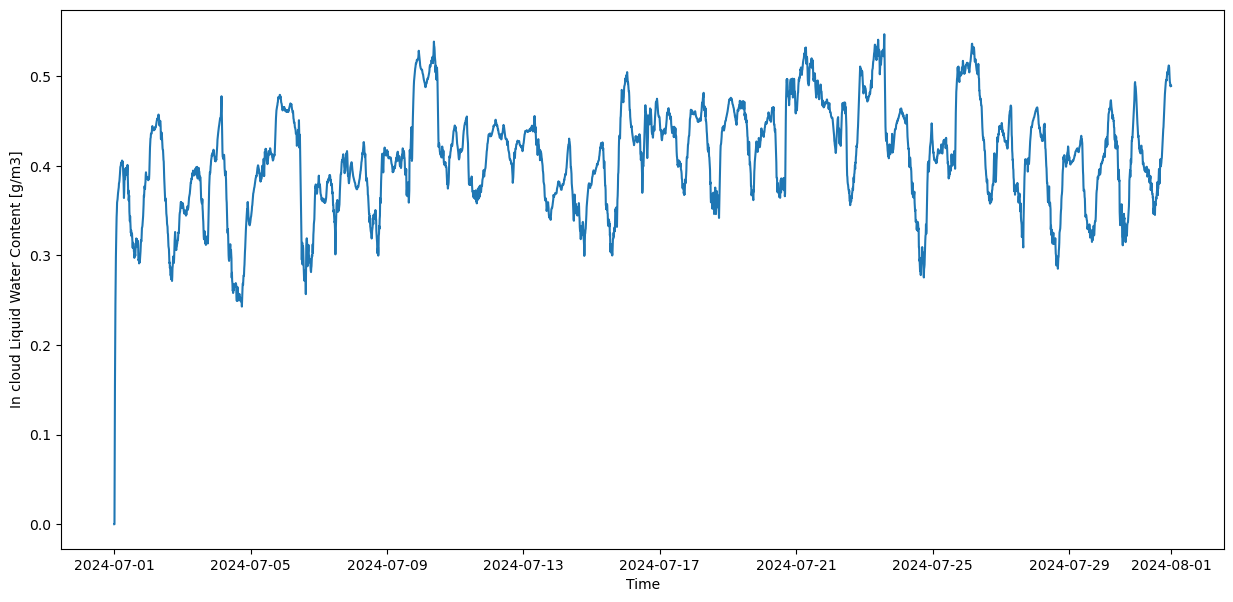

In [110]:
index_rain = np.where((P*3600 > 0.25))[0]
index_no_rain = np.where((rain_rate==0) & (P*3600 < 0.25))[0]
fig, ax = plt.subplots(figsize=(15,7))
ax.plot(measurements_used.time, X/Z_c_arr*1000)  # Adjust based on your data structure
ax.set_xlabel('Time')
ax.set_ylabel('In cloud Liquid Water Content [g/m3]')
# Add vertical lines at the corresponding times
#for idx in index_rain:
    #ax.axvline(measurements_used.time[idx].values, color='blue', linestyle='--', alpha=0.3)
#for idx in index_no_rain:
    #ax.axvline(measurements_used.time[idx].values, color='red', linestyle='--', alpha=0.3)



Text(0, 0.5, 'Cloud Top Pressure')

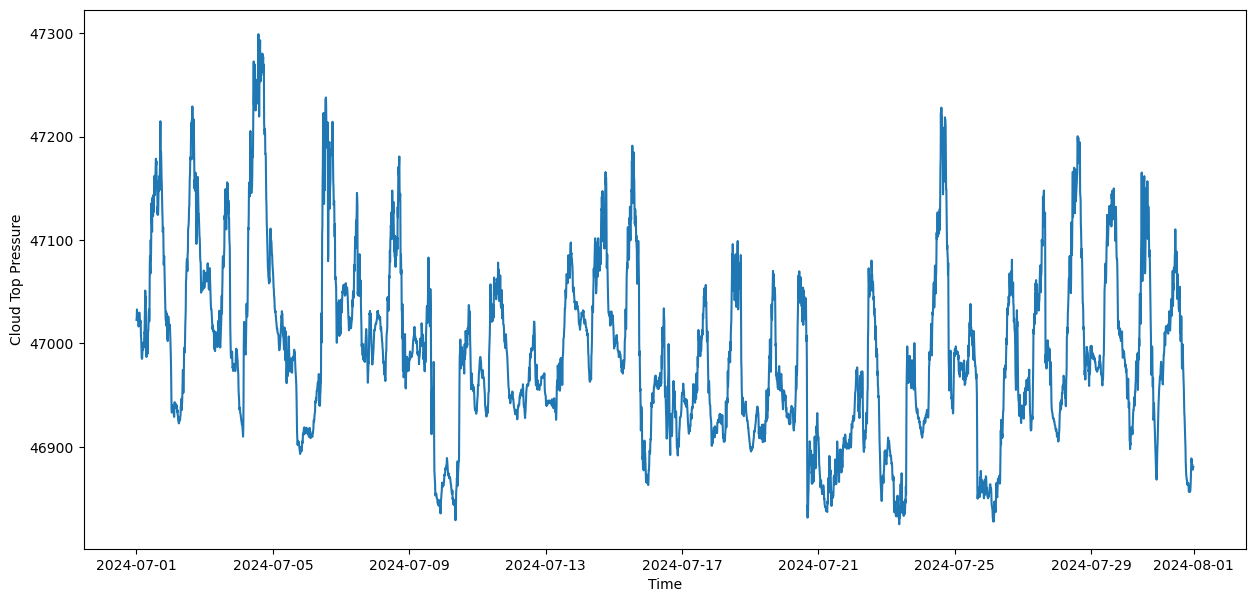

In [127]:
fig, ax = plt.subplots(figsize=(15,7))
ax.plot(measurements_used.time, p_t_arr)  # Adjust based on your data structure
ax.set_xlabel('Time')
ax.set_ylabel('Cloud Top Pressure')

Text(0, 0.5, 'Vertically Averaged Updraft Velocity [m/s]')

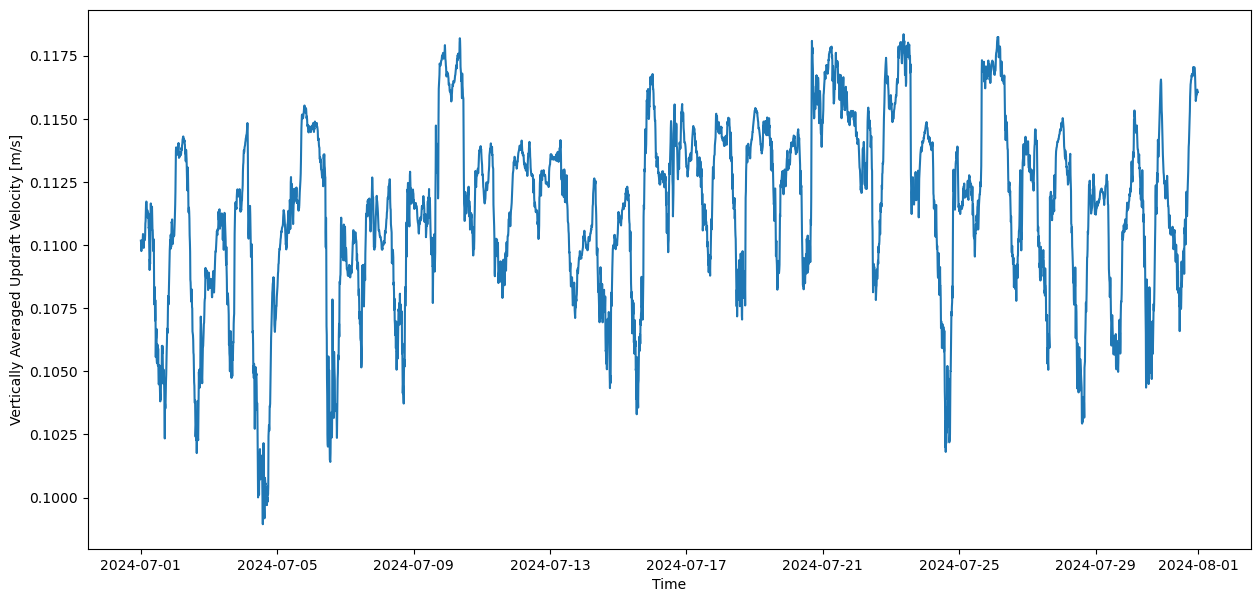

In [112]:
fig, ax = plt.subplots(figsize=(15,7))
ax.plot(measurements_used.time, v_updr_arr)  # Adjust based on your data structure
ax.set_xlabel('Time')
ax.set_ylabel('Vertically Averaged Updraft Velocity [m/s]')

Text(0.5, 0, 'time')

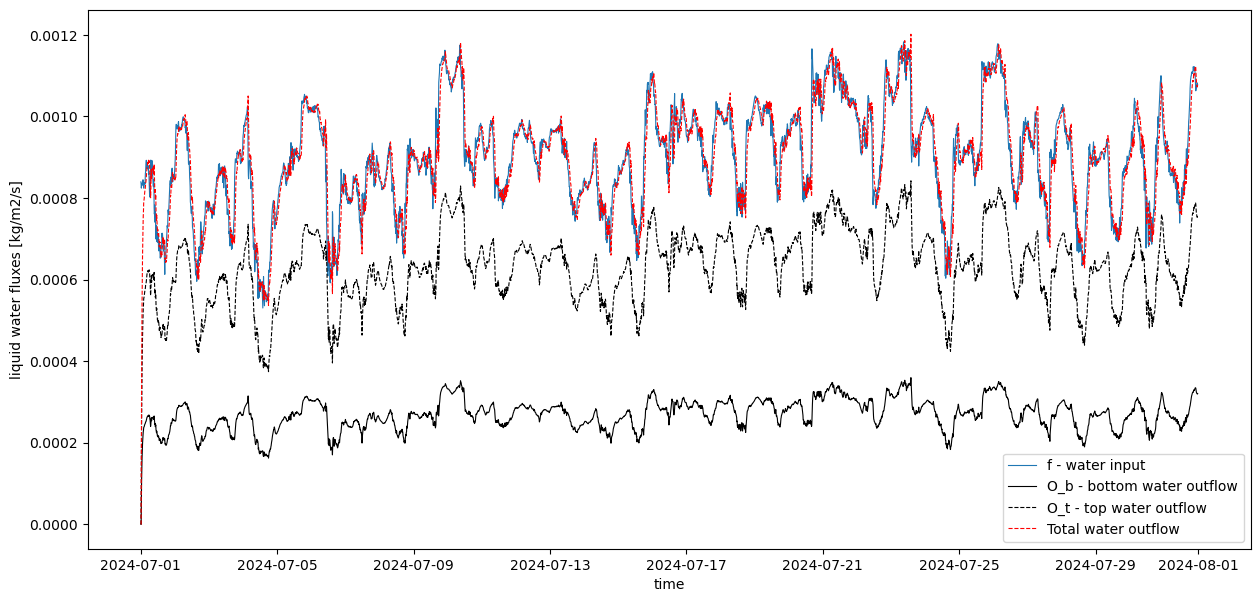

In [113]:
fig, ax = plt.subplots(figsize=(15,7))
plt.plot(measurements_used.time, f_arr,linewidth=0.8,label='f - water input')
plt.plot(measurements_used.time, O_b_arr*X,linewidth=0.8,label='O_b - bottom water outflow',color='black')
plt.plot(measurements_used.time, O_t_arr*X,linewidth=0.8,label='O_t - top water outflow',color='black',linestyle='--')
plt.plot(measurements_used.time, (O_t_arr+O_b_arr)*X,linewidth=0.8,label='Total water outflow',linestyle='--',color='red')
plt.legend()
plt.ylabel('liquid water fluxes [kg/m2/s]')
plt.xlabel('time')

In [114]:
f_arr

array([0.00083938, 0.00083549, 0.00082407, ..., 0.00108205, 0.001077  ,
       0.00107722])

In [115]:
np.max(X)

3.251080377899498

In [116]:
len(index_rain)

1401

In [117]:
print(np.mean(X))
print(np.mean(X[index_rain]))
print(np.mean(X[index_no_rain]))

2.288086249938395
2.6294264134228813
2.1347996574978723


### Plots and results

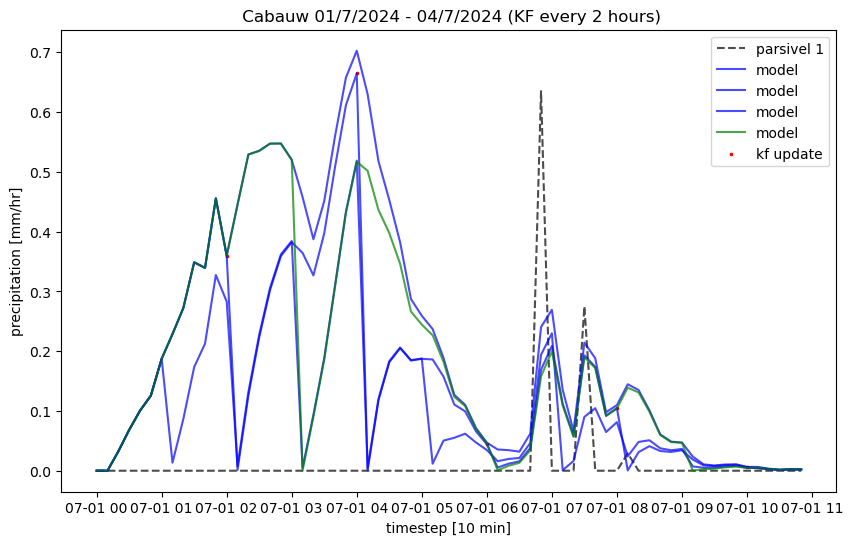

In [118]:
plt.figure(figsize=(10,6))
t_step = np.linspace(0,len(P),len(P))

slice_tuple_2 = ('2024-07-01 00:00:00', '2024-07-01 10:59:00')

indexes = measurements_used.sel(time=slice(*slice_tuple_2)).time
index_positions = [measurements_used.get_index("time").get_loc(t) for t in indexes.values]

#plt.plot(t_step,P_0*3600,label='model (steady state)')
plt.plot(measurements_used.time.sel(time=slice(*slice_tuple_2)),rain_rate.sel(time=slice(*slice_tuple_2)),label='parsivel 1',color='black',alpha=0.7,linestyle='--') 
plt.plot(measurements_used.time.sel(time=slice(*slice_tuple_2)),P[index_positions]*3600,label='model',color='blue',alpha=0.7)   #P [kg/m2/s] = P/1000kg/m3 = P/1000 m/s = P* 3600 [mm/hr]
plt.plot(measurements_used.time.sel(time=slice(*slice_tuple_2)),P_1[index_positions]*3600,label='model',color='blue',alpha=0.7)   #P [kg/m2/s] = P/1000kg/m3 = P/1000 m/s = P* 3600 [mm/hr]
plt.plot(measurements_used.time.sel(time=slice(*slice_tuple_2)),P_2[index_positions]*3600,label='model',color='blue',alpha=0.7)   #P [kg/m2/s] = P/1000kg/m3 = P/1000 m/s = P* 3600 [mm/hr]
plt.plot(measurements_used.time.sel(time=slice(*slice_tuple_2)),P_3[index_positions]*3600,label='model',color='green',alpha=0.7)   #P [kg/m2/s] = P/1000kg/m3 = P/1000 m/s = P* 3600 [mm/hr]
plt.scatter(measurements_used.time.sel(time=slice(*slice_tuple_2))[12::12],P_2[index_positions][12::12]*3600,label='kf update',marker='x',s=3,color='red')
plt.xlabel('timestep [10 min]')
plt.title(' Cabauw 01/7/2024 - 04/7/2024 (KF every 2 hours)')
plt.ylabel('precipitation [mm/hr]')
plt.legend()
#plt.grid()
plt.show()


In [119]:
len(P)

4464

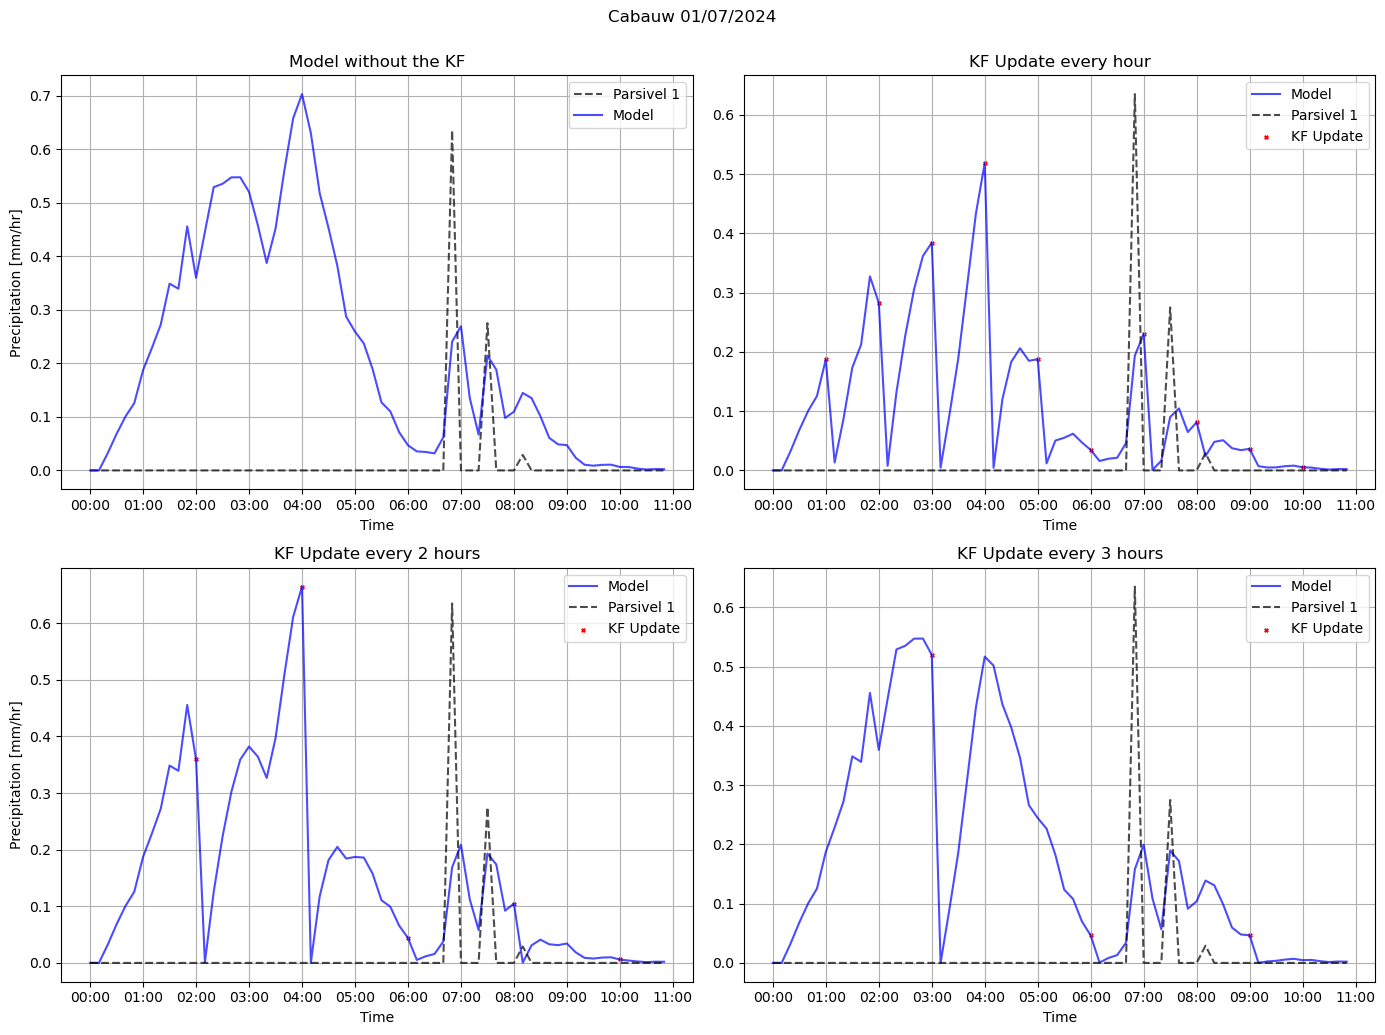

In [120]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
# Create a 2x2 grid for subplots
fig, axs = plt.subplots(2, 2, figsize=(14, 10)) 

# Example time series data (assuming these are already defined)
# measurements_used, rain_rate, P, P_1, P_2, P_3 need to be defined earlier in your code
t_step = np.linspace(0, len(P), len(P))

slice_tuple_2 = ('2024-07-01 00:00:00', '2024-07-01 10:59:00')

indexes = measurements_used.sel(time=slice(*slice_tuple_2)).time
index_positions = [measurements_used.get_index("time").get_loc(t) for t in indexes.values]

# Define the time slice for the plot
time_slice = measurements_used.time.sel(time=slice(*slice_tuple_2))

# Panel 1 - Plot model vs observed (rain rate)
axs[0, 0].plot(time_slice, rain_rate.sel(time=slice(*slice_tuple_2)), label='Parsivel 1', color='black', alpha=0.7, linestyle='--')
axs[0, 0].plot(time_slice, P[index_positions] * 3600, label='Model', color='blue', alpha=0.7)

axs[0, 0].set_title('Model without the KF')
axs[0, 0].set_xlabel('Time')
axs[0, 0].set_ylabel('Precipitation [mm/hr]')
axs[0, 0].legend()
axs[0, 0].grid()

# Panel 4 - Scatter plot (KF Update)
axs[0, 1].plot(time_slice, P_1[index_positions] * 3600, label='Model', color='blue', alpha=0.7)
axs[0, 1].plot(time_slice, rain_rate.sel(time=slice(*slice_tuple_2)), label='Parsivel 1', color='black', alpha=0.7, linestyle='--')
axs[0, 1].scatter(time_slice[6::6], P_1[index_positions][6::6] * 3600, label='KF Update', marker='x', s=6, color='red')
axs[0, 1].set_title('KF Update every hour')
axs[0, 1].set_xlabel('Time')
#axs[0, 1].set_ylabel('Precipitation [mm/hr]')
axs[0, 1].legend()
axs[0, 1].grid()


# Panel 3 - Plot Model P_3
axs[1, 0].plot(time_slice, P_2[index_positions] * 3600, label='Model', color='blue', alpha=0.7)
axs[1, 0].plot(time_slice, rain_rate.sel(time=slice(*slice_tuple_2)), label='Parsivel 1', color='black', alpha=0.7, linestyle='--')
axs[1, 0].scatter(time_slice[12::12], P_2[index_positions][12::12] * 3600, label='KF Update', marker='x', s=6, color='red')
axs[1, 0].set_title('KF Update every 2 hours')
#axs[1, 0].set_title('Model P_3')
axs[1, 0].set_xlabel('Time')
axs[1, 0].set_ylabel('Precipitation [mm/hr]')
axs[1, 0].legend()
axs[1, 0].grid()

# Panel 3 - Plot Model P_3
axs[1, 1].plot(time_slice, P_3[index_positions] * 3600, label='Model', color='blue', alpha=0.7)
axs[1, 1].plot(time_slice, rain_rate.sel(time=slice(*slice_tuple_2)), label='Parsivel 1', color='black', alpha=0.7, linestyle='--')
axs[1, 1].set_title('KF Update every 3 hours')
axs[1, 1].scatter(time_slice[18::18], P_3[index_positions][18::18] * 3600, label='KF Update', marker='x', s=6, color='red')
#axs[1, 0].set_title('Model P_3')
axs[1, 1].set_xlabel('Time')
#axs[1, 1].set_ylabel('Precipitation [mm/hr]')
axs[1, 1].legend()
axs[1, 1].grid()
for ax in axs.flat:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))  # Only display hour and minute
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))  # Set locator to show each hour (or adjust as needed)

# Adjust the layout and make sure everything fits well
plt.tight_layout()
plt.suptitle('Cabauw 01/07/2024 ', y=1.03)

# Show the plot
plt.show()


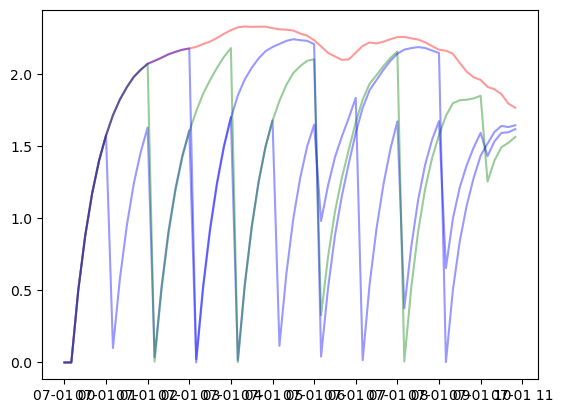

In [121]:
plt.plot(measurements_used.time.sel(time=slice(*slice_tuple_2)),X_1[index_positions],label='model',color='blue',alpha=0.4)
plt.plot(measurements_used.time.sel(time=slice(*slice_tuple_2)),X[index_positions],label='model',color='red',alpha=0.4)
plt.plot(measurements_used.time.sel(time=slice(*slice_tuple_2)),X_2[index_positions],label='model',color='green',alpha=0.4)
plt.plot(measurements_used.time.sel(time=slice(*slice_tuple_2)),X_3[index_positions],label='model',color='blue',alpha=0.4)   #P [kg/m2/s] = P/1000kg/m3 = P/1000 m/s = P* 3600 [mm/hr]

In [122]:
indexes = measurements_used.sel(time=slice(*slice_tuple_2)).time
index_positions = [measurements_used.get_index("time").get_loc(t) for t in indexes.values]
index_positions

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65]

(array([48., 38., 14., 14., 12., 13.,  7.,  9.,  8.,  7.,  5.,  7.,  4.,
         5.,  5.,  2.,  2.,  0.,  1.,  1.,  1.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  1.,  1.,  0.,  0.,
         0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  1.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([ 0.38499999,  0.64863998,  0.91228002,  1.17592001,  1.43956006,
         1.70319998,  1.96684003,  2.23047996,  2.49412012,  2.75776005,
         3.02139997,  3.28504014,  3.54868007,  3.81231999,  4.07596016,
         4.33960009,  4.60324001,  4.86687994,  5.13051987,  5.39416027,
         5.6578002 ,  5.92144012,  6.18508005,  6.44871998,  6.71235991,
         6.97600031,  7.23964024,  7.50328016,  7.76692009,  8.030560

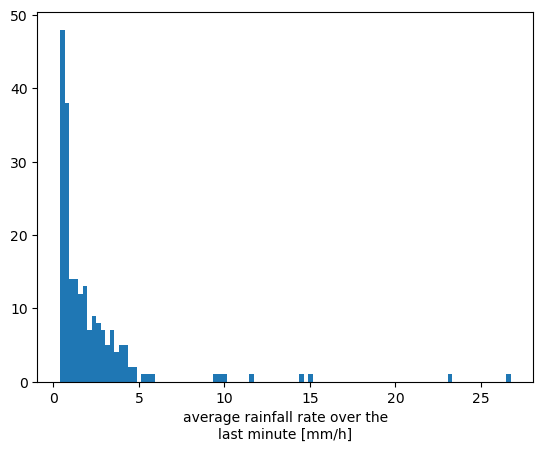

In [123]:
rain_rate.where(rain_rate>0.38).plot.hist(bins=100)

## Result analysis

In [124]:
np.sum((rain_rate>0.38))/len(rain_rate)

<xarray.DataArray 'rainfall_rate_32bit' ()> Size: 8B
array(0.04726703)

In [125]:
my_prec = P*3600
count_prec = np.sum((rain_rate>0.38) & (my_prec > 0.25))
count_no_prec = np.sum((rain_rate==0) & (my_prec<0.25))
count_model_dubious = np.sum(
    (rain_rate> 0) & (rain_rate <= 0.38) & (my_prec  < 0.38)) #& (P * 3600 > 0.25)) \
  #+ np.sum((rain_rate == 0) & (P * 3600 < 0.38) )
count_wrong_prec = np.sum((rain_rate==0) & (my_prec> 0.25)) + np.sum((rain_rate > 0) & (rain_rate <= 0.38) & (my_prec > 0.38))
count_wrong_zero = np.sum((rain_rate>0.38) & (my_prec< 0.25))

In [126]:
print(pearsonr(rain_rate,P_1*3600),pearsonr(rain_rate,P_2*3600),pearsonr(rain_rate,P_3*3600))
print(pearsonr(rain_rate[indices_1],P[indices_1]*3600))

PearsonRResult(statistic=0.2474656991615604, pvalue=2.8324873188502186e-63) PearsonRResult(statistic=0.2159510205926572, pvalue=2.939493657590158e-48) PearsonRResult(statistic=0.16310157631278016, pvalue=5.458488957633549e-28)


NameError: name 'indices_1' is not defined

In [ ]:
count_wrong_prec + count_model_dubious + count_prec + count_no_prec + count_wrong_zero

<xarray.DataArray 'rainfall_rate_32bit' ()> Size: 4B
array(4464)

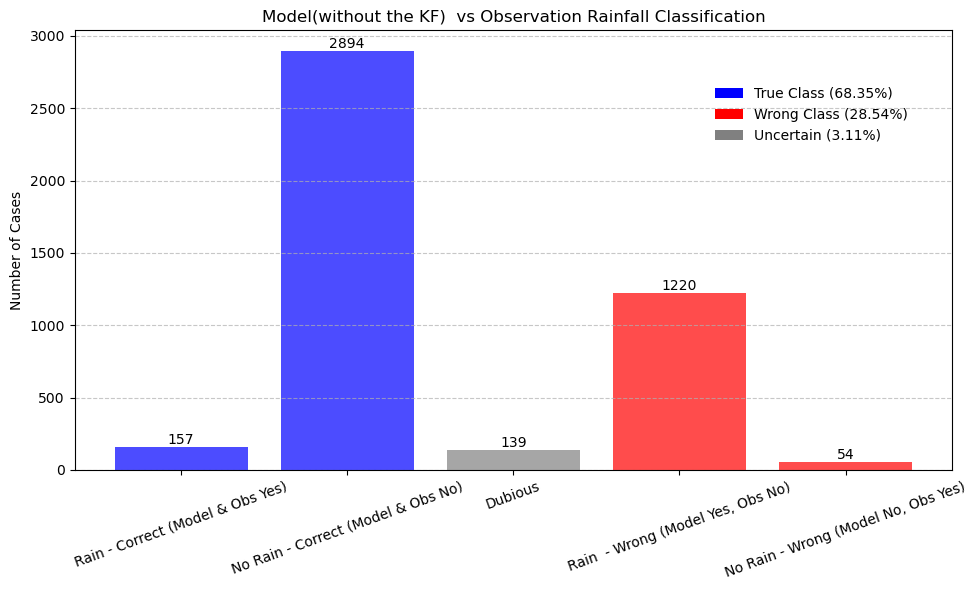

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
# Define labels and values
labels = [
    'Rain - Correct (Model & Obs Yes)',
    'No Rain - Correct (Model & Obs No)',
    'Dubious',
    'Rain  - Wrong (Model Yes, Obs No)',
    'No Rain - Wrong (Model No, Obs Yes)'
]

values = [
    count_prec,
    count_no_prec,
    count_model_dubious,
    
    count_wrong_prec,
    count_wrong_zero
]

# Create the bar plot
plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values, color=['blue', 'blue', 'gray','red', 'red'],alpha=0.7)

# Add count labels above bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom')

legend_elements = [
    Patch(facecolor='blue', label=f'True Class ({(count_prec+count_no_prec)/4464*100:.2f}%)'),
    #Patch(facecolor='blue', label='Correct No Rain'),
    #Patch(facecolor='orange', label='Dubious Cases'),
    Patch(facecolor='red', label=f'Wrong Class ({(count_wrong_prec+count_wrong_zero)/4464*100:.2f}%)'),#label='Correct No Rain'),
    Patch(facecolor='grey', label=f'Uncertain ({(count_model_dubious)/4464*100:.2f}%)')
]

# Add the custom legend at the top
plt.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.84, 0.9),
           ncol=1, frameon=False)
# Formatting
plt.title("Model(without the KF)  vs Observation Rainfall Classification")
plt.ylabel("Number of Cases")
plt.xticks(rotation=20)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


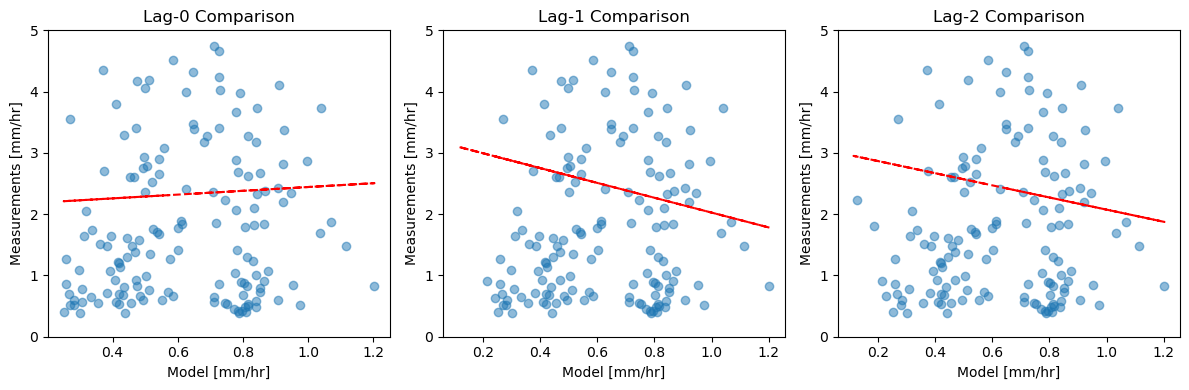

(0.0, 5.0)

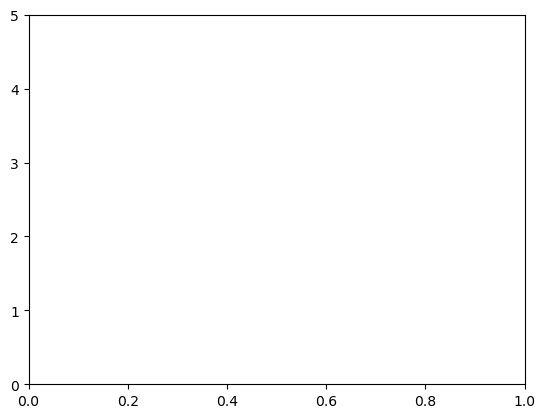

In [ ]:
import matplotlib.pyplot as plt

# Prepare indices
indices     = np.where((rain_rate > 0.38) & (P * 3600 > 0.25))
indices_1   = np.where((rain_rate[0:-1] > 0.38) & (P[1:] * 3600 > 0.25))
indices_2   = np.where((rain_rate[0:-2] > 0.38) & (P[2:] * 3600 > 0.25))

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=False)

# Panel 1: Lag 0
z_0 = np.polyfit(P[indices] * 3600, rain_rate[indices], 1)
p_0 = np.poly1d(z_0)
axes[0].scatter(P[indices] * 3600, rain_rate[indices], alpha=0.5)
axes[0].plot(P[indices] * 3600, p_0(P[indices] * 3600), "r--")
axes[0].set_title('Lag-0 Comparison')
axes[0].set_xlabel('Model [mm/hr]')
axes[0].set_ylabel('Measurements [mm/hr]')
axes[0].set_ylim(0, 5)

# Panel 2: Lag -1 (measurement leads model by 1)
z_1 = np.polyfit(P[indices_1] * 3600, rain_rate[indices_1], 1)
p_1 = np.poly1d(z_1)
axes[1].scatter(P[indices_1] * 3600, rain_rate[0:-1][indices_1], alpha=0.5)
axes[1].plot(P[indices_1] * 3600, p_1(P[indices_1] * 3600), "r--")
axes[1].set_title('Lag-1 Comparison')
axes[1].set_xlabel('Model [mm/hr]')
axes[1].set_ylabel('Measurements [mm/hr]')
axes[1].set_ylim(0, 5)
# Panel 3: Lag +1 (model leads measurement by 1)
z_2 = np.polyfit(P[indices_2] * 3600, rain_rate[indices_2], 1)
p_2 = np.poly1d(z_2)
axes[2].scatter(P[indices_2] * 3600, rain_rate[0:-2][indices_2], alpha=0.5)
axes[2].plot(P[indices_2] * 3600, p_2(P[indices_2] * 3600), "r--")
axes[2].set_title('Lag-2 Comparison')
axes[2].set_xlabel('Model [mm/hr]')
axes[2].set_ylabel('Measurements [mm/hr]')
axes[2].set_ylim(0, 5)
# Optional: consistent y-axis or limits
# for ax in axes:
#     ax.set_ylim(0, 10)
#     ax.set_xlim(0, 10)

plt.tight_layout()
plt.show()

plt.ylim(0,5)

In [ ]:
pearsonr(rain_rate,P*3600)

PearsonRResult(statistic=0.13128801606941207, pvalue=1.280156314892756e-18)

Text(0.5, 0, 'Model [mm/hr]')

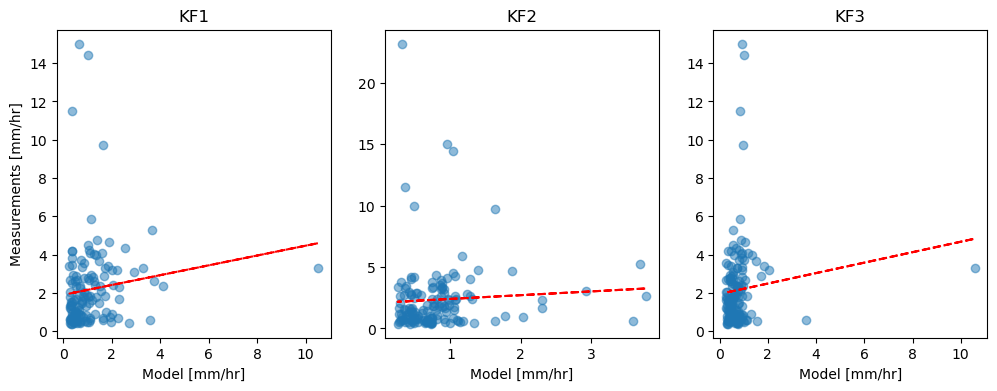

In [ ]:
my_prec_1 = P_1*3600
my_prec_2 = P_2*3600
my_prec_3 = P_3*3600

indices_1     = np.where((rain_rate > 0.38) & (my_prec_1 > 0.25))
indices_2     = np.where((rain_rate > 0.38) & (my_prec_2 > 0.25))
indices_3     = np.where((rain_rate > 0.38) & (my_prec_3 > 0.25))
# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(12,4), sharex=False)

# Panel 1: Lag 0
z_0 = np.polyfit(my_prec_1[indices_1], rain_rate[indices_1], 1)
p_0 = np.poly1d(z_0)
axes[0].scatter(my_prec_1[indices_1] , rain_rate[indices_1], alpha=0.5)
axes[0].plot(my_prec_1[indices_1], p_0(my_prec_1[indices_1] ), "r--")
axes[0].set_title('KF1')
axes[0].set_xlabel('Model [mm/hr]')
axes[0].set_ylabel('Measurements [mm/hr]')

z_0 = np.polyfit(my_prec_2[indices_2], rain_rate[indices_2], 1)
p_0 = np.poly1d(z_0)
axes[1].scatter(my_prec_2[indices_2] , rain_rate[indices_2], alpha=0.5)
axes[1].plot(my_prec_2[indices_2], p_0(my_prec_2[indices_2] ), "r--")
axes[1].set_title('KF2')
axes[1].set_xlabel('Model [mm/hr]')
#axes[0].set_ylabel('Measurements [mm/hr]')

z_0 = np.polyfit(my_prec_3[indices_3], rain_rate[indices_3], 1)
p_0 = np.poly1d(z_0)
axes[2].scatter(my_prec_3[indices_3] , rain_rate[indices_3], alpha=0.5)
axes[2].plot(my_prec_3[indices_3], p_0(my_prec_3[indices_3] ), "r--")
axes[2].set_title('KF3')
axes[2].set_xlabel('Model [mm/hr]')


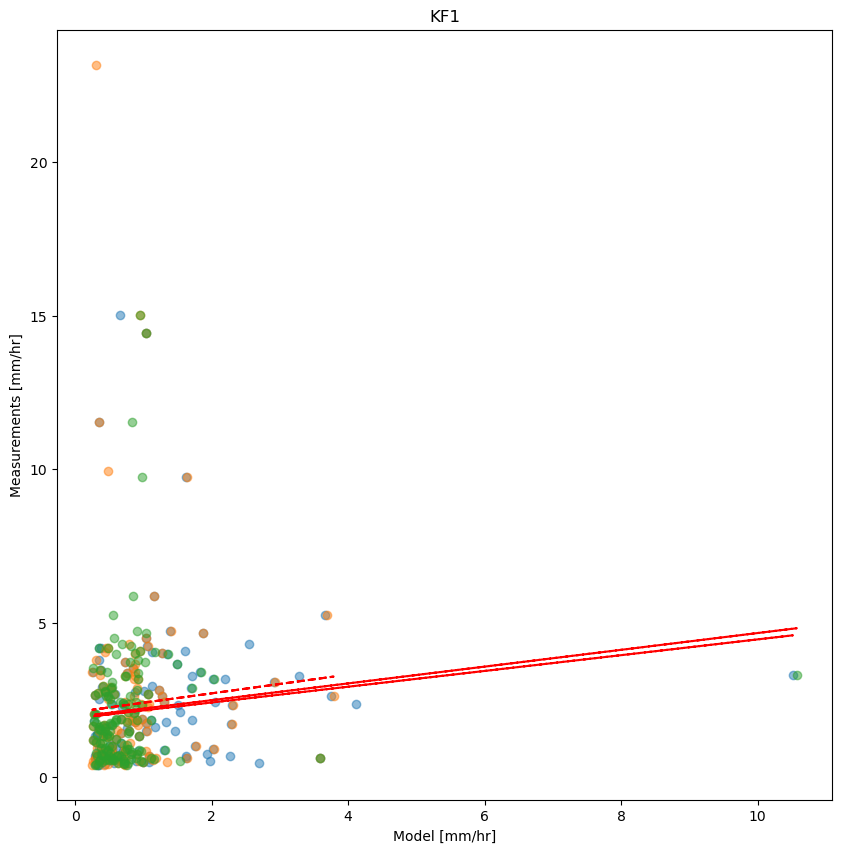

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(10,10), sharex=False)

# Panel 1: Lag 0
z_0 = np.polyfit(my_prec_1[indices_1], rain_rate[indices_1], 1)
p_0 = np.poly1d(z_0)
axes.scatter(my_prec_1[indices_1] , rain_rate[indices_1], alpha=0.5)
axes.plot(my_prec_1[indices_1], p_0(my_prec_1[indices_1] ), "r--")
axes.set_title('KF1')
axes.set_xlabel('Model [mm/hr]')
axes.set_ylabel('Measurements [mm/hr]')

z_0 = np.polyfit(my_prec_2[indices_2], rain_rate[indices_2], 1)
p_0 = np.poly1d(z_0)
axes.scatter(my_prec_2[indices_2] , rain_rate[indices_2], alpha=0.5)
axes.plot(my_prec_2[indices_2], p_0(my_prec_2[indices_2] ), "r--")
#axes[0].set_title('KF2')
#axes[0].set_xlabel('Model [mm/hr]')
#axes[0].set_ylabel('Measurements [mm/hr]')

z_0 = np.polyfit(my_prec_3[indices_3], rain_rate[indices_3], 1)
p_0 = np.poly1d(z_0)
axes.scatter(my_prec_3[indices_3] , rain_rate[indices_3], alpha=0.5)
axes.plot(my_prec_3[indices_3], p_0(my_prec_3[indices_3] ), "r--")
#axes[0].set_title('KF3')
#axes[0].set_xlabel('Model [mm/hr]')

In [ ]:
count_no_prec

<xarray.DataArray 'rainfall_rate_32bit' ()> Size: 4B
array(3098)

In [ ]:
correlation = signal.correlate(rain_rate, P*3600, mode="full")

lags = signal.correlation_lags(rain_rate.size, P.size, mode="full")

lag = lags[np.argmax(correlation)]

In [ ]:
print(pearsonr(rain_rate[indices_1],P_1[indices_1]*3600),pearsonr(rain_rate[indices_2],P_2[indices_2]*3600),pearsonr(rain_rate[indices_3],P_3[indices_3]*3600))
print(pearsonr(rain_rate,P*3600))

PearsonRResult(statistic=0.1283926044734034, pvalue=0.13485623825261278) PearsonRResult(statistic=0.06337491115401901, pvalue=0.4504710865270133) PearsonRResult(statistic=0.11231714367499157, pvalue=0.17117907048129)
PearsonRResult(statistic=0.13128801606941207, pvalue=1.280156314892756e-18)


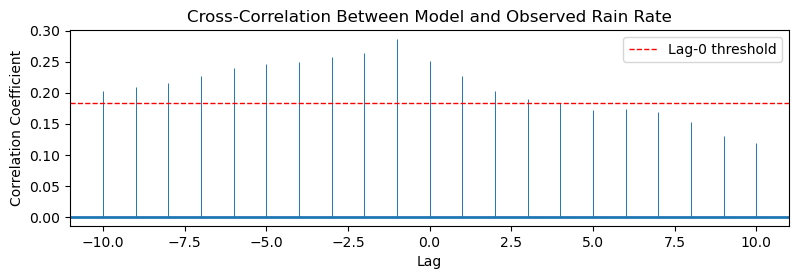

In [ ]:
import matplotlib.pyplot as plt

# Create the figure and axis
fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_subplot(211)

# Cross-correlation
ax1.xcorr(rain_rate, P_2 * 3600, usevlines=True,
          maxlags=10, normed=True,
          lw=2, linewidth=0.7)

# Horizontal reference line
ax1.axhline(y=0.18337568, color='r', linestyle='dashed', linewidth=1, label='Lag-0 threshold')

# Axis labels and title
ax1.set_title('Cross-Correlation Between Model and Observed Rain Rate')
ax1.set_xlabel('Lag')
ax1.set_ylabel('Correlation Coefficient')

# Add legend
ax1.legend(loc='upper right')

# Optional: adjust layout
plt.tight_layout()
plt.show()


ValueError: x and y must have same first dimension, but have shapes (4464,) and (432,)

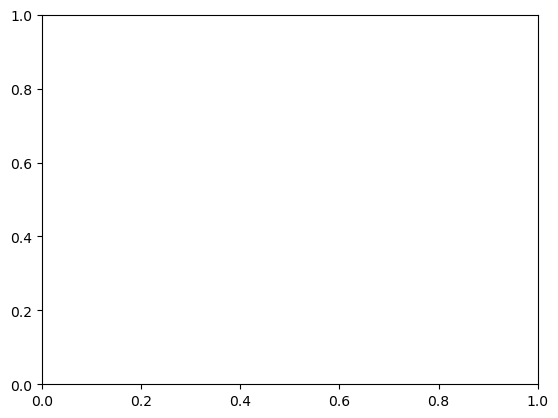

In [ ]:
plt.plot(t_step,rain_rate.sel(time=slice('2024-07-05 00:00:00', '2024-07-07 23:59:00')),label='observation')

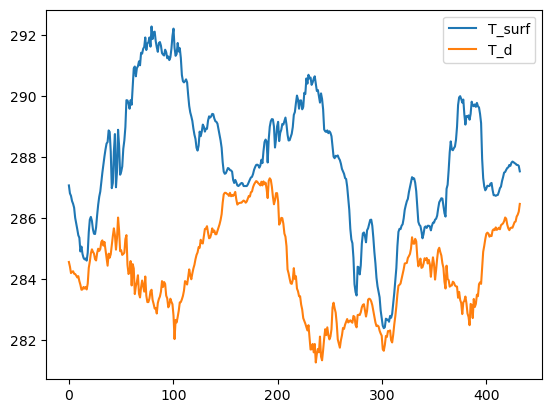

In [ ]:
plt.plot(t_step,T_surf,label='T_surf')
plt.plot(t_step,T_d_arr,label='T_d')
plt.legend()

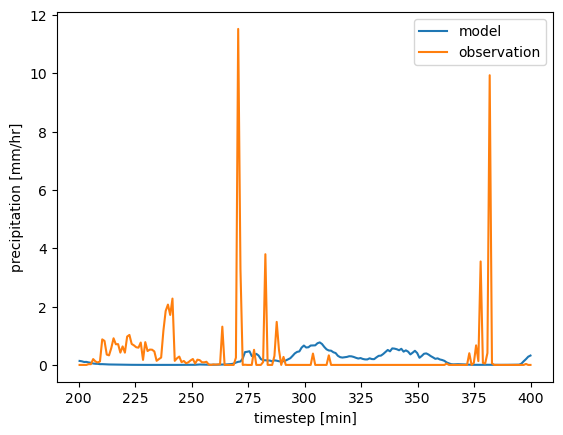

In [ ]:
#zooming when no rain is observed

t_step = np.linspace(0,len(P),len(P))
plt.plot(t_step[200:400],P[200:400]*3600,label='model')
plt.plot(t_step[200:400],rain_rate.sel(time=slice('2024-07-05 00:00:00', '2024-07-07 23:59:00'))[200:400],label='observation')
plt.legend()
plt.xlabel('timestep [min]')
plt.ylabel('precipitation [mm/hr]')
plt.show()


Text(0, 0.5, 'liquid water [kg/m^2]')

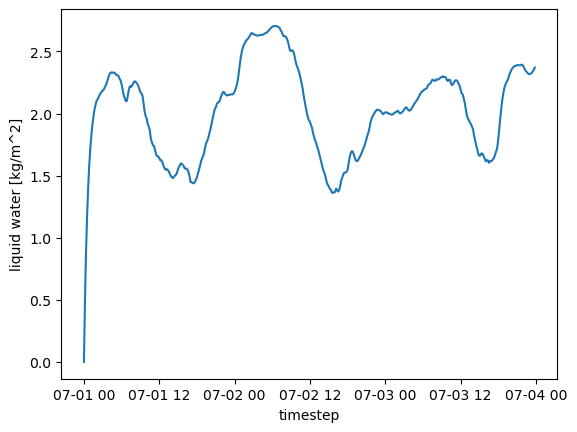

In [ ]:
#state evolution

plt.plot(measurements_used.time,X)
#plt.plot(july.time,july.lwp)
plt.xlabel('timestep')
plt.ylabel('liquid water [kg/m^2]')

Text(0, 0.5, 'average hourly precipitation (mm/hr)')

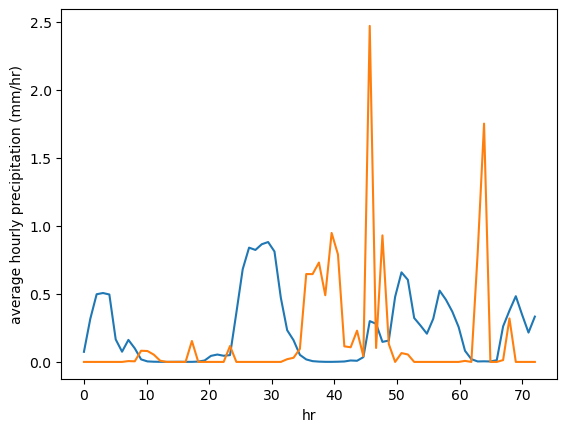

In [ ]:
Pmeas = rain_rate.sel(time=slice('2024-07-05 00:00:00', '2024-07-07 23:59:00'))
averages_P = [np.mean(P[i:i+6]) for i in range(0, len(P), 6)]
averages_Pmeas=[np.mean(Pmeas[i:i+6]) for i in range(0, len(P), 6)]
t_hr = np.linspace(0,len(averages_P),len(averages_P))

plt.plot(t_hr,np.array(averages_P)*3600,label='model (Kf)')   #P [kg/m2/s] = P/1000kg/m3 = P/1000 m/s = P* 3600 [mm/hr]
plt.plot(t_hr,averages_Pmeas,label='observation')
plt.xlabel('hr')
plt.ylabel('average hourly precipitation (mm/hr)')

In [ ]:
v_arr = np.zeros(len(T_surf))
O_b_arr = np.zeros(len(T_surf))
O_h_arr = np.zeros(len(T_surf))
I_arr = np.zeros(len(T_surf))

for i in range(0,len(T_surf)):
    #inputs
    T_0 = T_surf[i]
    p_0 = p_surf[i]
    T_d = T_d_arr[i]

    #meteorological variables
    p_s,T_s,p_t, T_m, T_t,T_s_up, p_s_up = variables(T_0, T_d, p_0, obs=False).run()
    rho = rho_m(T_s,T_t,p_s,p_t)
    v_updr = v(T_m,T_s_up)*5
    v_arr[i] = v_updr
    Z_c,Z_b = cloud_heights(T_s,T_t,T_0,p_s,p_t,p_0)
    O_b,O_t,h_v = h_out(v_updr,Z_c).run()   #outflows and sources of water
    print(non_dim_numbers(v_updr)[1])
    O_b_arr[i] = O_b*X[i]*non_dim_numbers(v_updr)[0]/Z_c
    O_h_arr[i] = O_t*X[i]*non_dim_numbers(v_updr)[0]/Z_c
    I_arr[i] = f(T_d,p_0,p_t,T_t,rho,v_updr)
     


2.861678495997993
2.8592679795489375
2.850955763799069
2.8557801536540404
2.858272230481497
2.856799343946523
2.8620726801773095
2.8628237671576504
2.8632645505356322
2.868506832716003
2.862414917763598
2.8643715629796858
2.8542271062454567
2.8587080445089583
2.8646032444141807
2.863100768499363
2.8649348069522125
2.8623637577984007
2.8669003691811596
2.879391186295834
2.881746501465455
2.8926424873080445
2.900806511249578
2.9019186702723085
2.9015168228761086
2.893482700136438
2.8879430166321924
2.892201492563092
2.8928219548620437
2.885132426389541
2.884947573766136
2.8900008840880274
2.8871039595394357
2.874588056360593
2.875553803920708
2.859893041536245
2.843920264695285
2.831480912221156
2.8428005873000686
2.8377312249308804
2.8544746268505246
2.890033052252707
2.899957783208608
2.893273838166988
2.8729558350203215
2.8823520108758114
2.8906499002718133
2.8966426228124753
2.886674668351837
2.8730779113001677
2.8727675204546252
2.8627670001225702
2.8538635253049933
2.85084319709035

KeyboardInterrupt: 

Text(0, 0.5, 'updraft velocity [m/s]')

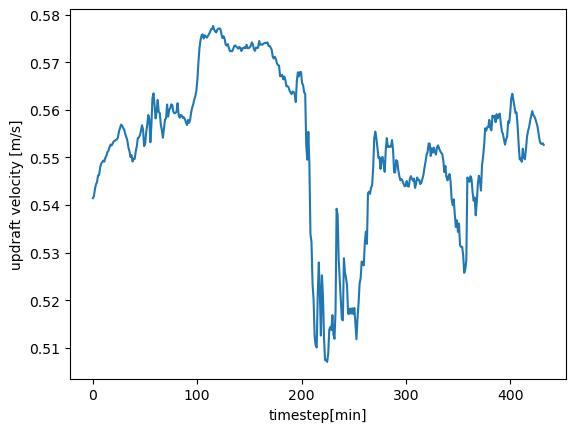

In [ ]:
plt.plot(t_step,v_arr)
plt.xlabel('timestep[min]')
plt.ylabel('updraft velocity [m/s]')

Text(0.5, 1.0, 'Cloud Fluxes')

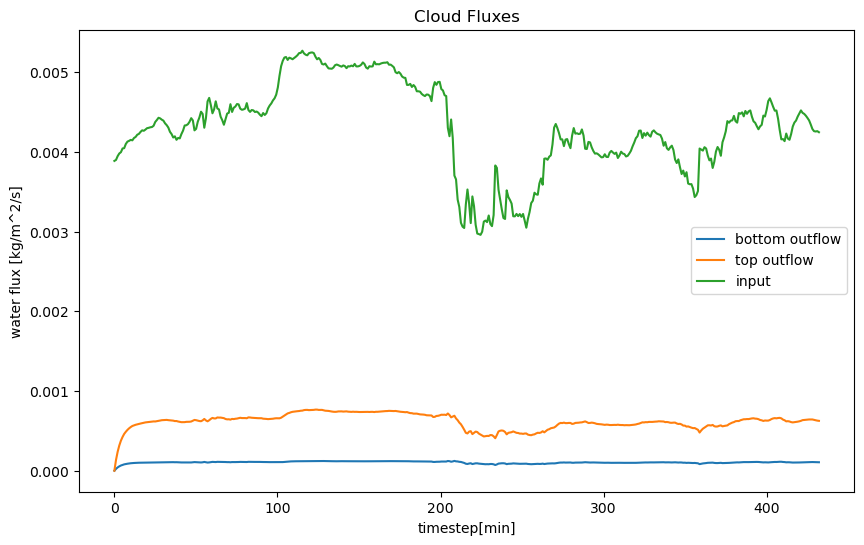

In [ ]:
A = np.zeros(30000)
#for i in range(0,3000):
    #if measurements['rain_rate'].values[7000+i]>0:
        #A[i] = t_step[i]
    #else:
        #A[i] = 0
    

plt.figure(figsize=(10,6))
plt.plot(t_step,O_b_arr,label='bottom outflow')
plt.plot(t_step,O_h_arr,label='top outflow')
plt.plot(t_step,I_arr,label='input')
plt.xlabel('timestep[min]')
plt.ylabel('water flux [kg/m^2/s]')
#plt.vlines(A,0,0.005,alpha=0.1,color='red')
plt.legend()
plt.title('Cloud Fluxes')

In [ ]:
O_b

0.3511910208066662

In [ ]:
X[i]*non_dim_numbers(v_updr)[0]/Z_c

array([0.00030251])

In [ ]:
T_t

array([246.24067734])